In [1]:
import sys
        # src/ 의 모듈을 불러오기 위한 경로

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

print('실행 중인 파이썬:', sys.executable)   # .venv 경로가 맞는지 확인!


# ── 자가 채점 도우미 ──────────────────────────────
_score = {}

def check(label, ok, hint=''):
    """조건 하나를 확인하고 결과를 출력한다."""
    ok = bool(ok)
    print(('  PASS  ' if ok else '  FAIL  ') + label
          + ('' if ok else '   ->  ' + hint))
    return ok

def grade(no, *conds):
    """문항 하나의 채점 결과를 기록한다."""
    _score[no] = all(conds)
    print(f"[문항 {no}] {'통과' if _score[no] else '미통과'}")

def summary():
    """전체 통과 현황을 요약한다."""
    passed = sum(_score.values())
    print(f'통과 {passed} / 시도 {len(_score)} 문항')
    bad = [k for k, v in _score.items() if not v]
    print('다시 볼 문항:', ', '.join(map(str, bad)) if bad else '없음')

실행 중인 파이썬: /home/pa31/Sparta/workspace/.venv/bin/python3


In [2]:
rng    = np.random.default_rng(0)          # 시드 고정 - 재현 가능한 실습
scan   = rng.random(360) * 12              # 각도별 거리 [m], 0~12
angles = np.linspace(0, 2*np.pi, 360)      # 각 측정의 각도 [rad]

print('scan  :', scan.shape, scan.dtype)
print('angles:', angles.shape)
print('처음 5개 거리:', np.round(scan[:5], 3))

scan  : (360,) float64
angles: (360,)
처음 5개 거리: [7.644 3.237 0.492 0.198 9.759]


In [3]:
_m = (scan > 0.1) & (scan < 10.0)
mask = _m
valid = scan[mask]
ratio = mask.mean()

# print(mask)
# print(ratio)
# print(scan[mask])

# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_m = (scan > 0.1) & (scan < 10.0)
grade(1,
      check('mask 가 불리언 배열', getattr(mask, 'dtype', None) == bool,
            '비교 연산 결과를 그대로 담으세요'),
      check('mask 의 내용이 정확', np.array_equal(mask, _m),
            '0.1 초과 AND 10 미만 - 등호 포함 여부와 괄호를 확인하세요'),
      check('valid 가 1차원', np.ndim(valid) == 1),
      check('valid 의 내용이 정확', np.array_equal(valid, scan[_m])),
      check('ratio 가 정확', np.isclose(ratio, _m.mean()),
            'ratio = 유효 개수 / 전체 개수'))

  PASS  mask 가 불리언 배열
  PASS  mask 의 내용이 정확
  PASS  valid 가 1차원
  PASS  valid 의 내용이 정확
  PASS  ratio 가 정확
[문항 1] 통과


In [4]:
near_dist = scan[_m].min()      # TODO
# print(scan[_m].min())

near_deg = np.degrees(
    angles[_m][np.argmin(scan[_m])]
    )
# print(np.argmin)
# print(near_deg)

print(f'최근접 {near_dist:.3f} m @ {near_deg:.1f} deg')

# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_i = np.argmin(scan[_m])
grade(2,
      check('near_dist 가 최솟값', np.isclose(near_dist, scan[_m].min())),
      check('near_deg 가 그 측정의 각도',
            np.isclose(near_deg, np.degrees(angles[_m][_i])),
            '무효 측정을 걸러낸 뒤의 인덱스를 각도에도 똑같이 적용하세요'),
      check('near_deg 가 0~360 범위', 0 <= near_deg <= 360))

최근접 0.119 m @ 150.4 deg
  PASS  near_dist 가 최솟값
  PASS  near_deg 가 그 측정의 각도
  PASS  near_deg 가 0~360 범위
[문항 2] 통과


In [5]:
# _m = (scan > 0.1) & (scan < 10.0)
ang_valid = angles[_m]      # TODO: 유효 측정의 각도만
x = scan[_m] * np.cos(ang_valid)
y = scan[_m] * np.sin(ang_valid)
xy = np.column_stack([x, y])
#xy        = np.cos(ang_valid)*np.sin(ang_valid)*scan[_m]**2 ==> 이건 아녀      # TODO: (N, 2)

print(xy.shape)
print(np.round(xy[:3], 3))

# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_r, _a = scan[_m], angles[_m]
_xy = np.column_stack([_r*np.cos(_a), _r*np.sin(_a)])
grade(3,
      check('xy 의 shape 가 (N, 2)', np.shape(xy) == _xy.shape,
            f'{_xy.shape} 가 나와야 합니다'),
      check('xy 의 값이 정확', np.allclose(xy, _xy),
            'x 는 cos, y 는 sin 입니다. 열 순서를 확인하세요'),
      check('원점까지 거리가 보존됨',
            np.allclose(np.linalg.norm(xy, axis=1), _r),
            '변환은 길이를 바꾸지 않아야 합니다'))

(284, 2)
[[7.644 0.   ]
 [3.237 0.057]
 [0.491 0.017]]
  PASS  xy 의 shape 가 (N, 2)
  PASS  xy 의 값이 정확
  PASS  원점까지 거리가 보존됨
[문항 3] 통과


In [6]:
# _m = (scan > 0.1) & (scan < 10.0)
_a = ang_valid
_r = scan[_m]
front  = (_a < np.pi/6) | (_a > 2*np.pi - np.pi/6)
danger = front & (scan[_m] < 1.5)
stop   = ...      # TODO 
#print(front)
#print(danger)
#print(stop)

print(f'전방 위험 측정 {danger.sum()}개 -> ' + ('정지' if stop else '주행'))

# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_f = (_a < np.pi/6) | (_a > 2*np.pi - np.pi/6)
_d = _f & (_r < 1.5)
grade(4,
      check('front 마스크가 정확', np.array_equal(front, _f),
            '0 근처와 2pi 근처 두 구간을 OR 로 이어야 합니다'),
      check('danger 마스크가 정확', np.array_equal(danger, _d)),
      check('stop 이 bool', isinstance(bool(stop), bool)),
      check('stop 판정이 정확', bool(stop) == bool(_d.any())))

전방 위험 측정 8개 -> 정지
  PASS  front 마스크가 정확
  PASS  danger 마스크가 정확
  PASS  stop 이 bool
  PASS  stop 판정이 정확
[문항 4] 통과


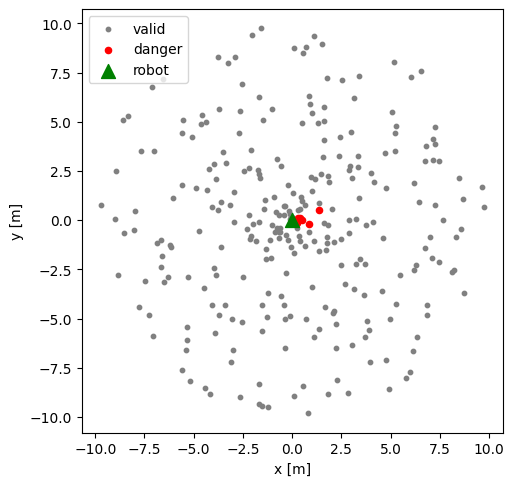

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
# TODO: ax.plot / ax.scatter 로 위 세 가지를 그리기
ax.scatter(xy[:, 0], xy[:, 1], s=10, c='gray', label='valid')
ax.scatter(xy[danger, 0],xy[danger, 1], s= 20, c='red', label='danger')
ax.scatter(0,0,marker='^' , s=100, c='green', label='robot')

ax.set_aspect('equal')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.legend()
plt.show()

In [8]:
th = np.radians(45)
R  = np.array([[_c, -_s], [_s, _c]])
xy_rot = ...  # TODO: (N, 2)

d0 = np.linalg.norm(xy, axis=1)
d1 = np.linalg.norm(xy_rot, axis=1)
print('거리 최대 차이:', np.abs(d0 - d1).max())

# ── 자가 채점 (이 셀은 수정하지 마세요) ──
_c, _s = np.cos(np.radians(45)), np.sin(np.radians(45))
_R = np.array([[_c, -_s], [_s, _c]])
grade(6,
      check('R 이 2x2', np.shape(R) == (2, 2)),
      check('R 이 45도 회전행렬', np.allclose(R, _R),
            '[[cos, -sin], [sin, cos]] 순서를 확인하세요'),
      check('xy_rot 의 shape 가 유지됨', np.shape(xy_rot) == np.shape(xy)),
      check('회전이 길이를 보존', np.allclose(d0, d1),
            '길이가 변했다면 곱하는 순서나 전치를 확인하세요'))

NameError: name '_c' is not defined